---
title: "Conditional marginals & density estimation"
short_title: "01 · Conditional density"
subtitle: "A continuous context y: estimate p(x|y) across the whole range, verify each slice Gaussianizes to N(0,I), and see when y-dependent marginals suffice versus when the couplings must carry it"
description: >
  Notebook 00 used a discrete class label; here the context y is continuous. We fit a
  conditional flow to a 2-D family p(x|y) that morphs with y, sweep the learned
  density across the context, verify the Gaussianization direction (each slice maps to
  N(0,I)), and contrast a couplings-conditioned flow against a marginals/diagonal one —
  the answer to "when do y-dependent margins suffice?".
---

(sec-nb-cond-01)=
# 01 — Conditional marginals & density estimation

In [00](00_three_ways_to_condition.ipynb) the context was a discrete class label.
The more common case is a **continuous** context $y$: a covariate, a sensor setting,
a forcing. The conditional flow then estimates a whole *curve* of densities
$p(x\mid y)$, with the usual conditional change of variables

$$
p(x\mid y) = p_Z\big(T_\theta(x; y)\big)\,\big|\det J_{T_\theta(\cdot;y)}(x)\big|,
$$

and — keeping a **fixed** $\mathcal{N}(0,I)$ base — the map $T_\theta(\cdot\mid y)$ is a
genuine *conditional Gaussianizer*: every slice $p(x\mid y)$ is carried to the **same**
standard normal. That gives us back the diagnostic notebook 00 had to skip: push a
slice's data through $T_\theta(\cdot\mid y)$ and check it lands on $\mathcal{N}(0,I)$.

The other question this notebook answers is **7.2 — when do you condition the
marginals versus the couplings?** A conditional *marginal* makes each coordinate's
CDF depend on $y$ — cheap, and enough when the coordinates are conditionally
independent given $y$. The moment $y$ induces *dependence* between coordinates, only a
conditional **coupling** can follow it. We make that concrete on a family that bends.

**What you will see**

- A 2-D conditional $p(x\mid y)$ that **morphs** with a continuous $y$.
- The learned density and samples **swept across $y$**.
- The **Gaussianization check**: each slice $T_\theta(\cdot\mid y)$-maps to $\mathcal{N}(0,I)$.
- **Couplings vs marginals**: the marginal/diagonal model captures spread but cannot
  bend — the rule of thumb for 7.2.

In [1]:
import warnings

warnings.filterwarnings("ignore")

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import optax
from flowjax.bijections import Chain, Permute
from flowjax.distributions import Normal, Transformed
from flowjax.train import fit_to_data
from scipy import stats

from gauss_flows import ConditionalDiagGaussian, RQSplineCoupling, RQSplineMarginal
from _style import DATA_COLOR, GAUSS_KW, LATENT_COLOR, SCATTER_KW, style_ax

jax.config.update("jax_enable_x64", True)

## 1. A conditional family that bends

Draw $u\sim\mathcal{N}(0,I_2)$ and set
$x_1 = 0.8\,u_1$, $x_2 = 0.6\,u_2 + 1.5\,y\,\tanh(1.2\,u_1)$. The context $y$ controls
an **S-shaped tilt**: at $y=0$ the two coordinates are independent ($x_2$ is just
noise); as $|y|$ grows $x_2$ rises with $x_1$ for $y>0$ and falls for $y<0$, tilting and
bending the cloud. So $y$ changes both the *shape* of $p(x\mid y)$ and the *dependence*
between $x_1$ and $x_2$ — while the $\tanh$ keeps tails bounded (a raw $u_1^2$ bend
blows the spline's support). We standardise $x$ with fixed stats.

X (5000, 2), context Y (5000, 1), y in [-1.5, 1.5]  (standardised x)


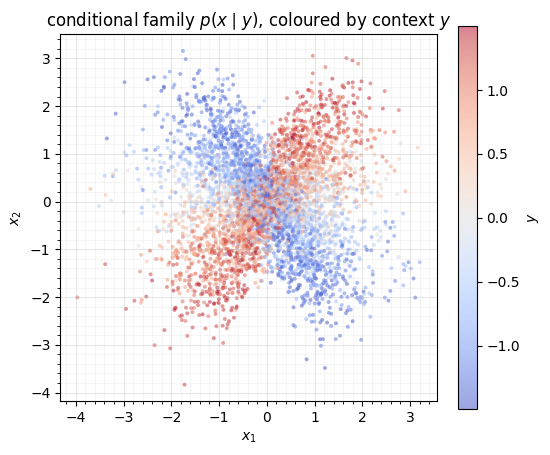

In [2]:
Y_LO, Y_HI = -1.5, 1.5


def sample_banana(key, n, y_fixed=None):
    ku, ky = jr.split(key)
    y = (jnp.full((n, 1), y_fixed) if y_fixed is not None
         else jr.uniform(ky, (n, 1), minval=Y_LO, maxval=Y_HI))
    u = jr.normal(ku, (n, 2))
    x1 = 0.8 * u[:, 0]
    x2 = 0.6 * u[:, 1] + 1.5 * y[:, 0] * jnp.tanh(1.2 * u[:, 0])
    return jnp.stack([x1, x2], -1), y


# Fixed standardisation stats from a large pilot sample.
_pilot, _ = sample_banana(jr.key(99), 20000)
X_MEAN, X_STD = _pilot.mean(0), _pilot.std(0)


def dataset(key, n, y_fixed=None):
    x, y = sample_banana(key, n, y_fixed)
    return (x - X_MEAN) / X_STD, y


X, Y = dataset(jr.key(0), 5000)
print(f"X {X.shape}, context Y {Y.shape}, y in [{Y_LO}, {Y_HI}]  (standardised x)")

# colour the cloud by y to show the morphing family in one panel
fig, ax = plt.subplots(figsize=(5.6, 5))
sc = ax.scatter(np.asarray(X[:, 0]), np.asarray(X[:, 1]), c=np.asarray(Y[:, 0]),
                cmap="coolwarm", s=8, alpha=0.5, edgecolors="none")
ax.set(title="conditional family $p(x\\mid y)$, coloured by context $y$",
       xlabel="$x_1$", ylabel="$x_2$")
ax.set_aspect("equal"); style_ax(ax)
fig.colorbar(sc, ax=ax, label="$y$", fraction=0.046)
fig.tight_layout()

## 2. A couplings-conditioned flow

A fixed $\mathcal{N}(0,I)$ base plus a chain of `RQSplineCoupling(cond_dim=1)` layers
(the context $y$ is concatenated into each conditioner) with `Permute`s between them.
Built as a flowjax `Transformed` so we can call `chain.inverse(x, y)` — the
Gaussianization map — directly. We train by conditional NLL.

In [3]:
def make_coupling_flow(key, n_layers=5):
    keys = jr.split(key, n_layers)
    perm = jnp.array([1, 0])
    transforms = []
    for i, k in enumerate(keys):
        transforms.append(RQSplineCoupling(k, shape=(2,), n_bins=8, interval=5.0,
                                           cond_dim=1, nn_width=64, nn_depth=2))
        if i < n_layers - 1:
            transforms.append(Permute(perm))
    return Transformed(Normal(jnp.zeros(2)), Chain(transforms))


def train(dist, key, max_epochs=300):
    steps = -(-int(X.shape[0] * 0.9) // 256)
    lr = optax.cosine_decay_schedule(3e-3, decay_steps=max_epochs * steps, alpha=0.02)
    opt = optax.chain(optax.clip_by_global_norm(5.0), optax.adam(lr))
    trained, losses = fit_to_data(key, dist, (X, Y), optimizer=opt, max_epochs=max_epochs,
                                  max_patience=max_epochs, batch_size=256, val_prop=0.1,
                                  show_progress=False)
    return trained, losses


cpl, cpl_losses = train(make_coupling_flow(jr.key(1)), jr.key(2))
print(f"coupling flow: {len(cpl_losses['train'])} epochs, val NLL {float(min(cpl_losses['val'])):+.4f}")

coupling flow: 300 epochs, val NLL +2.2626


## 3. The learned density, swept across the context

The point of a conditional model: one trained flow gives $p(x\mid y)$ for *any* $y$.
Top row — true data sampled at each $y$; bottom row — the flow's density on a grid at
the same $y$. The learned banana bends the right way and by the right amount as $y$
moves from $-1.2$ to $+1.2$.

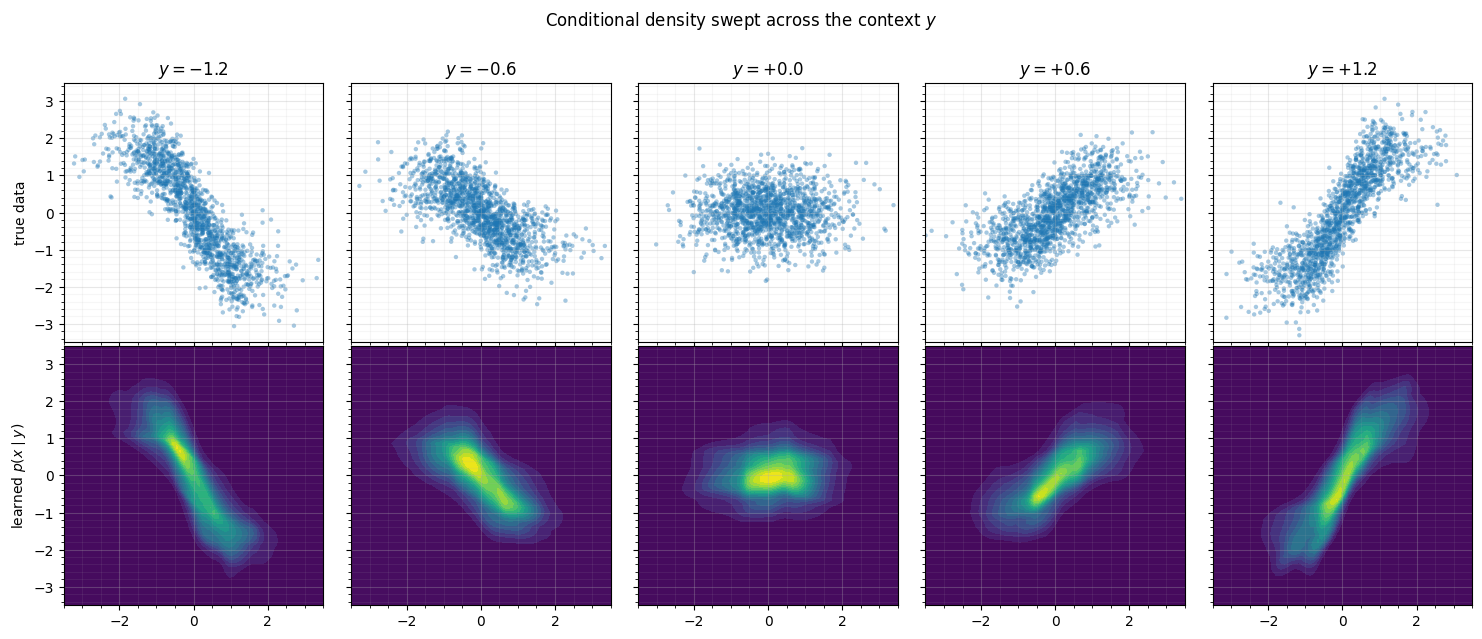

In [4]:
y_slices = jnp.array([-1.2, -0.6, 0.0, 0.6, 1.2])
lim, gn = 3.5, 70
xs = jnp.linspace(-lim, lim, gn)
gx, gy = jnp.meshgrid(xs, xs)
grid = jnp.stack([gx.ravel(), gy.ravel()], -1)


@eqx.filter_jit
def density_at(dist, yv):
    c = jnp.array([yv])  # context is the raw y value
    return jnp.exp(jax.vmap(lambda p: dist.log_prob(p, condition=c))(grid)).reshape(gn, gn)


fig, axes = plt.subplots(2, len(y_slices), figsize=(15, 6.2), sharex=True, sharey=True)
for j, yv in enumerate(y_slices):
    xt, _ = dataset(jr.fold_in(jr.key(7), j), 1500, y_fixed=float(yv))
    axes[0, j].scatter(np.asarray(xt[:, 0]), np.asarray(xt[:, 1]), color=DATA_COLOR, **SCATTER_KW)
    axes[0, j].set(title=f"$y={float(yv):+.1f}$", xlim=(-lim, lim), ylim=(-lim, lim))
    axes[1, j].contourf(np.asarray(gx), np.asarray(gy), np.asarray(density_at(cpl, float(yv))),
                        levels=18, cmap="viridis")
    for r in (0, 1):
        axes[r, j].set_aspect("equal"); style_ax(axes[r, j])
axes[0, 0].set_ylabel("true data")
axes[1, 0].set_ylabel("learned $p(x\\mid y)$")
fig.suptitle("Conditional density swept across the context $y$", y=1.01)
fig.tight_layout()

## 4. The Gaussianization check

Because the base is a fixed $\mathcal{N}(0,I)$, the map $T_\theta(\cdot\mid y) =$
`chain.inverse(x, y)` should send **every** slice to the same standard normal. We push
each slice's data through it and look: the conditional bananas all collapse onto the
$\mathcal{N}(0,I)$ rings, with moments near $(0,1,0,0)$ regardless of $y$.

Gaussianized-slice moments (target 0, 1, 0, 0):


  y=-1: mean=(+0.10,+0.06)  std=(0.99,0.89)  exc-kurt=(-0.20,-0.33)


  y=+0: mean=(-0.09,-0.03)  std=(1.00,0.90)  exc-kurt=(-0.05,-0.07)


  y=+1: mean=(-0.08,+0.01)  std=(1.06,0.92)  exc-kurt=(+0.10,-0.03)


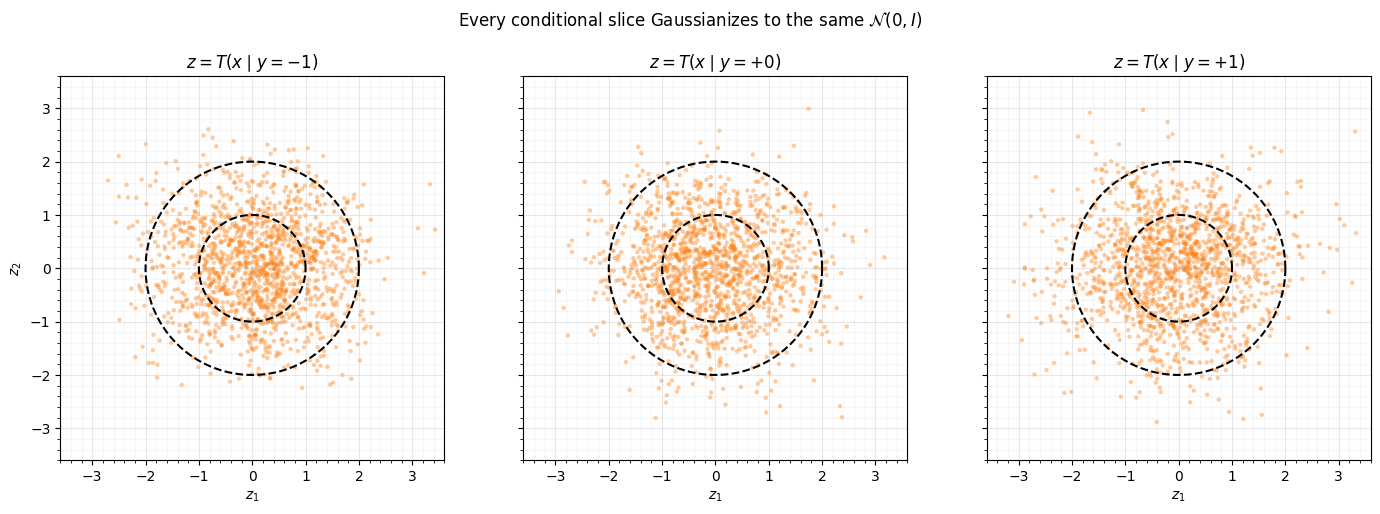

In [5]:
chain = cpl.bijection
th = np.linspace(0, 2 * np.pi, 200)
check_ys = [-1.0, 0.0, 1.0]
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8), sharex=True, sharey=True)
print("Gaussianized-slice moments (target 0, 1, 0, 0):")
for ax, yv in zip(axes, check_ys):
    xt, _ = dataset(jr.fold_in(jr.key(13), int((yv + 2) * 10)), 1500, y_fixed=yv)
    c = jnp.array([yv])
    z = np.asarray(jax.vmap(lambda p: chain.inverse(p, condition=c))(xt))
    ax.scatter(z[:, 0], z[:, 1], color=LATENT_COLOR, **SCATTER_KW)
    for r in (1.0, 2.0):
        ax.plot(r * np.cos(th), r * np.sin(th), **GAUSS_KW)
    ax.set(title=f"$z = T(x\\mid y={yv:+.0f})$", xlabel="$z_1$", xlim=(-3.6, 3.6), ylim=(-3.6, 3.6))
    ax.set_aspect("equal"); style_ax(ax)
    print(f"  y={yv:+.0f}: mean=({z[:,0].mean():+.2f},{z[:,1].mean():+.2f})  "
          f"std=({z[:,0].std():.2f},{z[:,1].std():.2f})  "
          f"exc-kurt=({stats.kurtosis(z[:,0]):+.2f},{stats.kurtosis(z[:,1]):+.2f})")
axes[0].set_ylabel("$z_2$")
fig.suptitle(r"Every conditional slice Gaussianizes to the same $\mathcal{N}(0,I)$", y=1.02)
fig.tight_layout()

Three different bananas, one standard normal — that is the conditional Gaussianizer
working. (Compare notebook 00, where `SurVAEFlow` did not expose this forward map; a
flowjax `Transformed` does.)

## 5. When do y-dependent marginals suffice? (7.2)

A cheaper option conditions only the **margins** — here a `ConditionalDiagGaussian`
base (per-coordinate $y$-dependent location/scale) with *unconditional* spline margins
and **no coupling**. Such a model can stretch and shift each axis with $y$, but it
treats the coordinates as independent given $y$, so it cannot represent the banana's
$y$-induced dependence. We fit it and compare.


mean conditional NLL (lower is better):


  marginal / diagonal (y -> base only): +2.7301


  coupling (y -> couplings)           : +2.2395


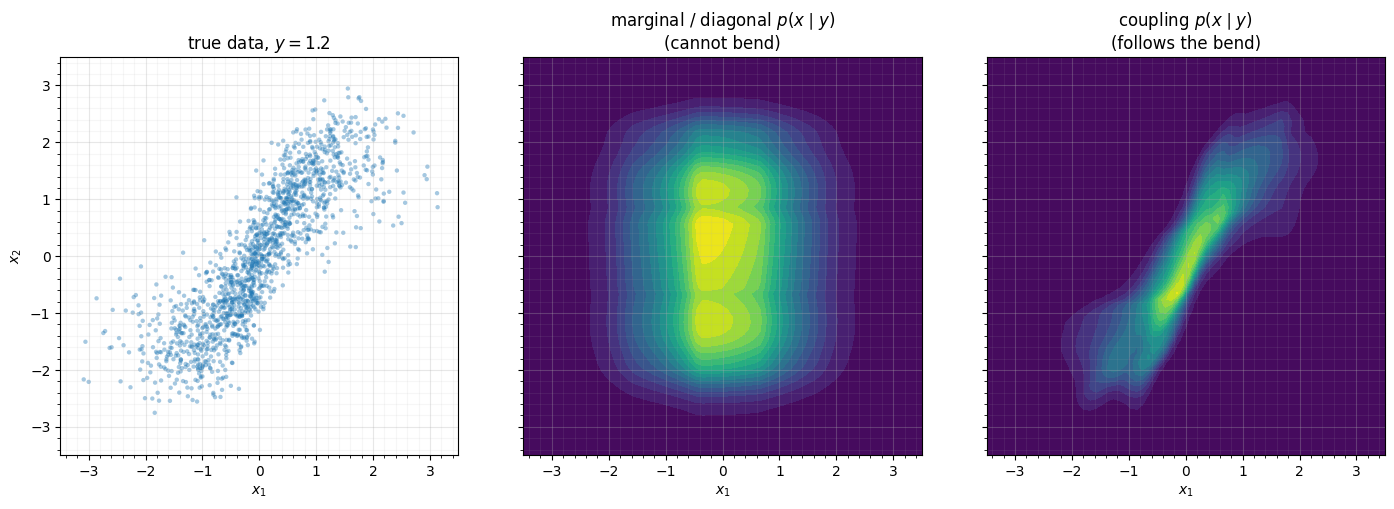

In [6]:
def make_diagonal_flow(key, n_layers=3):
    base = ConditionalDiagGaussian(key, event_shape=(2,), cond_shape=(1,))
    margins = [RQSplineMarginal(n_bins=8, shape=(2,), interval=5.0) for _ in range(n_layers)]
    return Transformed(base, Chain(margins))


diag, diag_losses = train(make_diagonal_flow(jr.key(3)), jr.key(4))


def mean_nll(dist):
    f = eqx.filter_jit(lambda x, c: jax.vmap(lambda xi, ci: dist.log_prob(xi, condition=ci))(x, c))
    return -float(jnp.mean(f(X, Y)))


print(f"\nmean conditional NLL (lower is better):")
print(f"  marginal / diagonal (y -> base only): {mean_nll(diag):+.4f}")
print(f"  coupling (y -> couplings)           : {mean_nll(cpl):+.4f}")

yv = 1.2
xt, _ = dataset(jr.key(21), 1500, y_fixed=yv)
fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.8), sharex=True, sharey=True)
axes[0].scatter(np.asarray(xt[:, 0]), np.asarray(xt[:, 1]), color=DATA_COLOR, **SCATTER_KW)
axes[0].set(title=f"true data, $y={yv}$")
axes[1].contourf(np.asarray(gx), np.asarray(gy), np.asarray(density_at(diag, yv)), levels=18, cmap="viridis")
axes[1].set(title="marginal / diagonal $p(x\\mid y)$\n(cannot bend)")
axes[2].contourf(np.asarray(gx), np.asarray(gy), np.asarray(density_at(cpl, yv)), levels=18, cmap="viridis")
axes[2].set(title="coupling $p(x\\mid y)$\n(follows the bend)")
for ax in axes:
    ax.set(xlim=(-lim, lim), ylim=(-lim, lim), xlabel="$x_1$")
    ax.set_aspect("equal"); style_ax(ax)
axes[0].set_ylabel("$x_2$")
fig.tight_layout()

The diagonal model widens $x_2$ as $|y|$ grows — it sees the *marginal* spread — but
its density stays an axis-aligned blob, because no elementwise margin can make $x_2$
depend on $x_1$. The coupling flow bends with the data and wins on NLL.

## Recap

| $y$ changes... | enough to condition... | why |
|---|---|---|
| per-coordinate **location / scale** | **marginals** (or the base) | coordinates stay independent given $y$ |
| per-coordinate **shape** (skew, tails) | **marginals** (richer CDF) | still elementwise |
| the **dependence** between coordinates | **couplings** (`cond_dim`) | only a coupling reads one coordinate to transform another |

So: reach for conditional **marginals** when $y$ only reshapes each axis, and for
conditional **couplings** the moment $y$ couples the axes — which the banana does. With
a fixed $\mathcal{N}(0,I)$ base, the trained coupling flow is a conditional
Gaussianizer that maps every slice $p(x\mid y)$ to the same standard normal, as the
check in §4 confirmed.

**Next up.** [02 — Conditional flow as an amortised posterior](02_amortised_posterior.ipynb)
turns the context into an *observation* $y = Ax + \eta$ and trains $p(x\mid y)$ as a
one-pass posterior for an inverse problem — the bridge to the plug-and-play priors of
Part 16.